# 💻 **Actividad 2**

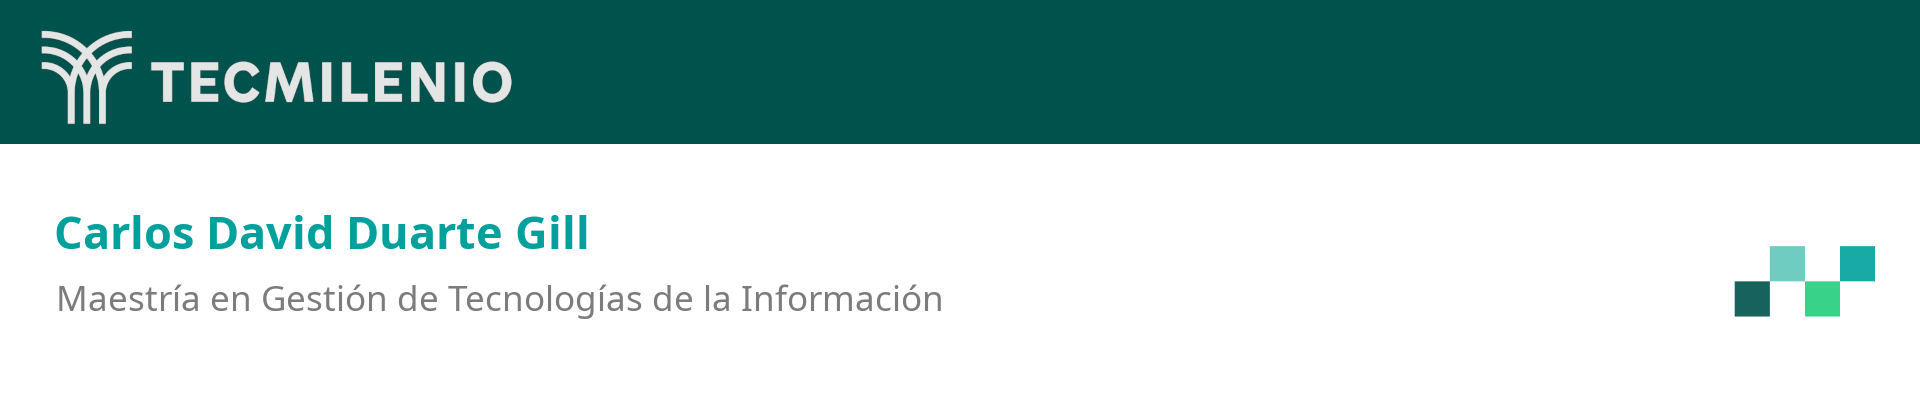

## **Aplicaciones avanzadas en ciencia de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Martín Antonio Santos Romero
- Fecha:  domingo 29 de marzo de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 📘 Introducción – Actividad 2

En esta segunda fase del proyecto se continua revisando el escenario de NovaCredit, esta vez desde una perspectiva de predicción y descubrimiento, con la intención de entender por qué los clientes incumplen con sus pagos y si existen grupos de clientes con comportamientos similares que requieran un trato diferente. Para ello se emplearán los modelos de ensamble para aumentar la precisión de alertas de riesgo y técnicas de aprendizaje no supervisado para revelar segmentos ocultos en la cartera de clientes.

## 🗽 Alcance y alcance de la Actividad 2

El objetivo principal de esta actividad es diseñar un modelo que permita anticipar el riesgo de default y segmentar la cartera de clientes de manera estratégica en favor del negocio. Esto conlleva:

- Construir modelos predictivos utilizando algoritmos de ensamble.
- Optimizar el rendimiento de los modelos mediante la búsqueda de hiperparámetros.
- Identificar perfiles de clientes "especiales" mediante clustering para poder diseñar estrategias de cobranza y prevención personalizadas.

# 💻 Entorno Python para la Actividad 2

Se creó un nuevo entorno de trabajo optimizada para el análisis de datos masivos...

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la Actividad 2 y asegurar todos los pasos requeridos durante su desarrollo, se utilizará el conjunto de datos **novacredit_clientes_limpio
.csv** preparado durante la Actividad 1.

### 📒 Acerca del conjunto de datos

El conjunto de datos preparado `novacredit_clientes_limpio.csv` cuenta con 10,000 registros y 21 variables. Este nuevo archivo representa una versión optimizada del historial de clientes, diseñada específicamente para ser interpretada por algoritmos de aprendizaje automático.

Características principales:
- El dataset original paso por un proceso de limpieza y ya no existen valores nulos ni errores de encoding detectados anteriormente.
- Todas las variables numéricas han sido escaladas previamente mediante StandardScaler.
- Las variables categóricas de texto se han transformado en representaciones numéricas mediante técnicas de One-Hot Encoding y Ordinal Encoding.
- Se aplicaron técnicas de capping para reducir el efecto de los outliers en límites de crédito y saldos.

### 🔗 Carga el conjunto de datos en url pública

Para el desarrollo de la Actividad 2 se cargo previamente el nuevo dataset en un [repositorio público en GitHub](https://raw.githubusercontent.com/RamRider89/aplicaciones-ciencia-datos/refs/heads/main/actividades/actividad-2/novacredit_clientes_limpio.csv)

# 💻 Desarrollo de la Actividad 2

**A continuación:**

🧰 Se importan las librerías necesarias para el desarrollo de los modelos necesarios.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [1]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import sys
import os
# warnings
import warnings
warnings.filterwarnings('ignore')

try:
    # liberias basicas
    import pandas as pd
    import numpy as np

    # Herramientas necesarios
    import sklearn
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
    from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, roc_auc_score

    # visualizacion
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tabulate import tabulate


    print("-" * 80)
    print("⚙️ Cargando librerías core...")
    print(f"Python: {sys.version.split()[0]}")
    print(f"Pandas version: {pd.__version__}")
    print(f"NumPy version: {np.__version__}")
    print(f"scikit-learn version: {sklearn.__version__}")


    print("-" * 80)
    print("⚙️ Cargando librerías de visualización...")
    print(f"Matplotlib - version: {plt.matplotlib.__version__}")
    print(f"Seaborn version: {sns.__version__}")
    print("-" * 80)
    print("🚀 ¡Entorno preparado!")
    print("-" * 80)

except Exception as e:
    print(f"❌ Error de entorno, favor de instalar las dependencias necesarias: {e}")

warnings.filterwarnings('ignore')

--------------------------------------------------------------------------------
⚙️ Cargando librerías core...
Python: 3.10.19
Pandas version: 2.3.3
NumPy version: 2.2.6
scikit-learn version: 1.7.2
--------------------------------------------------------------------------------
⚙️ Cargando librerías de visualización...
Matplotlib - version: 3.10.0
Seaborn version: 0.13.2
--------------------------------------------------------------------------------
🚀 ¡Entorno preparado!
--------------------------------------------------------------------------------


## 🗂 Variables de entorno

In [63]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_primary="#007bff"
_color_gray="#6c757d"
_color_white="#ffffff"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"

# Muted
_Gold_ = '#f0c571'
_Teal_ = '#59a89c'
_Blue_ = '#0b81a2'
_Red_ = '#e25759'
_Dark_Red_ = '#9d2c00'
_Purple_ = '#7E4794'
_Green_ = '#36b700'
_Gray_ = '#c8c8c8'

# paletas
_paleta_muted_ = [_Gold_, _Teal_, _Blue_, _Red_, _Dark_Red_, _Purple_, _Green_, _Gray_]
_paleta3_ = [_color_tecmi_light, _color_info, _color_warning]
# configuración de estilo visual
sns.set_theme(style="whitegrid")

### 🗂 Funciones auxiliares

In [3]:
# --------------------------------------------------------------------------
# 🤖 display mensaje
# --------------------------------------------------------------------------
def display_mensaje(msj):
    print("\n" + "="*80)
    print("\033[1m --- " + msj + " --- \033[0m")
    print("="*80)

In [4]:
# ------------------------------------------------------------------------------
# 🤖 diccionario builder
# ------------------------------------------------------------------------------

def dictionary_builder(columnas_categoricas, msj):

    _dict_unique_values_ = {}

    # recorremos las columnas categoricas para obtener sus valores
    display_mensaje(msj)
    # recorreos las columnas categoricas
    for col in columnas_categoricas.columns:
        # obtenemos los vals unicos
        unique_values = columnas_categoricas[col].unique()
        # asignamos los valores unicos al dict
        _dict_unique_values_[col] = columnas_categoricas[col].unique()


    # para mostrar el resultado del diccionario en pantalla
    # convertimos el diccionario a un conjunto de listas
    data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

    # definimos los titulos de la tabla
    headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
    # imprimiendo
    print(tabulate(data, headers=headers, tablefmt="grid"))

    return _dict_unique_values_;

# 💾 Carga de los datos

Para iniciar el análisis se utiliza la url pública del dataset en **Canvas**.

In [5]:
# ------------------------------------------------------------------------------
# CARGA DEL DATASET
# ------------------------------------------------------------------------------
# URL pública del dataset
_URL_REPO_ = 'https://raw.githubusercontent.com/RamRider89/aplicaciones-ciencia-datos/refs/heads/main/actividades/actividad-2/novacredit_clientes_limpio.csv'
_URL_LOCAL_ = "./novacredit_clientes_limpio.csv"
_URL_ = _URL_LOCAL_
# config
pd.set_option('display.max_columns', None)

# leyendo el archivo csv mediante pandas
df_prep = pd.read_csv(_URL_)

# 🔍 Análisis exploratorio inicial

A continuación se inicia con el análisis inicial del dataset.

## 🗂 Descripción del dataframe

In [6]:
display_mensaje("Estructura inicial del DataFrame")
df_prep.head()


 --- Estructura inicial del DataFrame --- 


,edad,ingreso_mensual,antiguedad_cliente_meses,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m,region_Norte,region_Sur,canal_adquisicion_Referido,canal_adquisicion_Sucursal,canal_adquisicion_Web,tipo_producto_Préstamo,tipo_producto_Tarjeta,tipo_contrato_Mensual,metodo_pago_Efectivo,metodo_pago_Transferencia,segmento_cliente,default_12m
0,0.459957,-0.235277,-0.961132,-0.538530,-0.212932,0.463622,0.466275,1.625988,-0.488493,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1
1,-0.141845,-0.467831,3.467460,-0.314700,-0.319937,-0.169499,-0.699413,-1.098827,-0.488493,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,0
2,0.631900,-0.640340,0.661224,-0.884979,-0.847772,-0.802620,-0.466275,-0.190555,0.324172,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1
3,1.577588,-0.163460,1.099698,-0.444092,-0.938128,-1.435741,0.932550,-1.098827,0.324172,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0
4,-0.227816,1.103756,0.222749,1.465018,-0.273586,-1.119180,1.165688,0.717716,0.324172,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,1


## 🗂 Información de la estructura

In [7]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   edad                        10000 non-null  float64
 1   ingreso_mensual             10000 non-null  float64
 2   antiguedad_cliente_meses    10000 non-null  float64
 3   limite_credito              10000 non-null  float64
 4   saldo_promedio              10000 non-null  float64
 5   porcentaje_utilizacion      10000 non-null  float64
 6   num_transacciones_mes       10000 non-null  float64
 7   pagos_atrasados_12m         10000 non-null  float64
 8   reclamos_12m                10000 non-null  float64
 9   region_Norte                10000 non-null  float64
 10  region_Sur                  10000 non-null  float64
 11  canal_adquisicion_Referido  10000 non-null  float64
 12  canal_adquisicion_Sucursal  10000 non-null  float64
 13  canal_adquisicion_Web       1000

In [8]:
display_mensaje("Estructura del Dataset")
print(f"Dataset shape: {df_prep.shape}")
print(f"Número de filas: {df_prep.shape[0]}")
print(f"Número de columnas: {df_prep.shape[1]}")


 --- Estructura del Dataset --- 
Dataset shape: (10000, 21)
Número de filas: 10000
Número de columnas: 21


### 🕵️‍♂️ Tipos de datos

A continuación, se detalla la estructura del nuevo dataset resultante tras el preprocesamiento de limpieza:

| Categoría             | Variable(s)                                                                                                                                                       | Tipo de Dato | Transformación Aplicada | Propósito en el Modelo                                                                                        |
| --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------ | ----------------------- | ------------------------------------------------------------------------------------------------------------- |
| Numéricas Escaladas   | edad, ingreso_mensual, antiguedad_cliente_meses, limite_credito, saldo_promedio, porcentaje_utilizacion, num_transacciones_mes, pagos_atrasados_12m, reclamos_12m | float64      | StandardScaler          | Capturar la magnitud y varianza de los indicadores financieros y de comportamiento sin sesgos por escala.     |
| Geográficas (Nominal) | region_Norte, region_Sur                                                                                                                                          | float64      | One-Hot Encoding        | Identificar patrones de riesgo específicos por ubicación geográfica.                                          |
| Origen (Nominal)      | canal_adquisicion_Referido, canal_adquisicion_Sucursal, canal_adquisicion_Web                                                                                     | float64      | One-Hot Encoding        | Evaluar si el canal de entrada del cliente influye en la probabilidad de default.                             |
| Producto (Nominal)    | tipo_producto_Préstamo, tipo_producto_Tarjeta                                                                                                                     | float64      | One-Hot Encoding        | Diferenciar el comportamiento de riesgo según el instrumento financiero contratado.                           |
| Contrato (Nominal)    | tipo_contrato_Mensual                                                                                                                                             | float64      | One-Hot Encoding        | Analizar la estabilidad del cliente según la duración de su compromiso contractual.                           |
| Pago (Nominal)        | metodo_pago_Efectivo, metodo_pago_Transferencia                                                                                                                   | float64      | One-Hot Encoding        | Detectar si ciertos métodos de pago están correlacionados con el incumplimiento.                              |
| Perfil (Ordinal)      | segmento_cliente                                                                                                                                                  | float64      | Ordinal Encoding        | Representar la jerarquía de valor del cliente (Básico < Plus < Premium) mediante valores numéricos (0, 1, 2). |
| Objetivo (Target)     | default_12m                                                                                                                                                       | int64        | Ninguna                 | Variable a predecir: indica si el cliente incumplió sus pagos (1) o no (0).                                   |

# 🕵️‍♂️ Verificación técnica del dataset

Para garantizar que el Actividad 2 se desarrolle sobre un dataset confiable, se realiza a continuación una verificación técnica del dataset preparado.

## 🔍 Verificación de integridad y consistencia

En este bloque se confirma que el escalamiento sea correcto revisando que la media sea cercana a 0 y la desviación estándar cercana a 1, y que no hayan quedado valores de nulos o valores infinitos.

In [9]:
# ------------------------------------------------------------------------------
# Verificación de integridad y consistencia
# ------------------------------------------------------------------------------
def verificar_consistencia(df):
    display_mensaje("Verificación de integridad y consistencia")
    
    # comprobar nulos
    nulos = df.isnull().sum().sum()
    
    # comprobar valores infinitos
    infinitos = np.isinf(df.select_dtypes(include=np.number)).values.sum()
    
    # validar escalamiento solo en variables float64 que fueron estandarizadas
    cols_escaladas = ['edad', 'ingreso_mensual', 'antiguedad_cliente_meses', 'limite_credito', 
                      'saldo_promedio', 'porcentaje_utilizacion', 'num_transacciones_mes', 
                      'pagos_atrasados_12m', 'reclamos_12m']
    
    mean_check = df[cols_escaladas].mean().abs().mean()
    std_check = df[cols_escaladas].std().mean()

    print(f"Total de nulos: {nulos}")
    print(f"Total de infinitos: {infinitos}")
    print(f"Media promedio: {mean_check:.6f}")
    print(f"Desviación estándar promedio: {std_check:.6f}")
    
    if nulos == 0 and infinitos == 0 and abs(mean_check) < 0.1:
        print("\n✅ RESULTADO: Dataset consistente para modelación.")
    else:
        print("\n⚠️ ADVERTENCIA: Se detectaron inconsistencias en el dataset.")

verificar_consistencia(df_prep)


 --- Verificación de integridad y consistencia --- 
Total de nulos: 0
Total de infinitos: 0
Media promedio: 0.000000
Desviación estándar promedio: 1.000050

✅ RESULTADO: Dataset consistente para modelación.


## 🔍 Análisis de capacidad predictiva

En este bloque se visualiza rápidamente cuáles son las variables de mayor influencia en el negocio de NovaCredit. Esto nos ayudará a entender mejor el dataset para el diseño del modelo.


 --- Análisis de capacidad predictiva - Objetivo: default_12m --- 


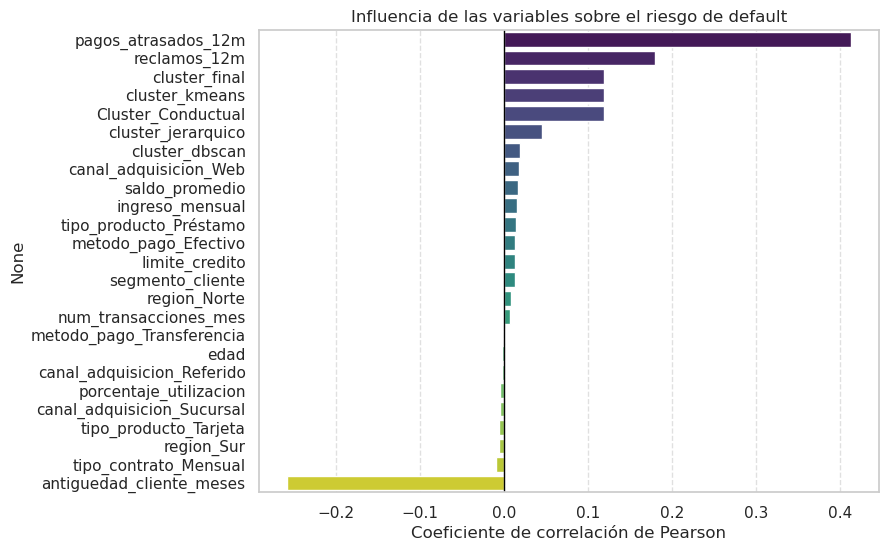


 --- Top 3 variables que aumentan el riesgo --- 
pagos_atrasados_12m   0.412
reclamos_12m          0.180
cluster_final         0.119
Name: default_12m, dtype: float64

 --- Top 3 variables que disminuyen riesgo --- 
region_Sur                 -0.006
tipo_contrato_Mensual      -0.009
antiguedad_cliente_meses   -0.258
Name: default_12m, dtype: float64


In [91]:
# ------------------------------------------------------------------------------
# 🔍 Análisis de capacidad predictiva
# ------------------------------------------------------------------------------
def analizar_predictoras(df):
    # objetivo
    target='default_12m'
    
    display_mensaje("Análisis de capacidad predictiva - Objetivo: default_12m")
    
    # calcular correlación de Pearson
    correlaciones = df.corr()[target].sort_values(ascending=False)
    
    # visualización
    plt.figure(figsize=(8, 6))
    # datos graficos sin el objetivo
    correlaciones_plot = correlaciones.drop(target)
    
    sns.barplot(
                x=correlaciones_plot.values, 
                y=correlaciones_plot.index, 
                palette='viridis')
    
    plt.title('Influencia de las variables sobre el riesgo de default')
    plt.xlabel('Coeficiente de correlación de Pearson')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.savefig('figs/1-influencia-de-variables.png')
    plt.show()
    
    # resultados del top 3 mas influyentes
    display_mensaje("Top 3 variables que aumentan el riesgo")
    print(correlaciones_plot.head(3))
    display_mensaje("Top 3 variables que disminuyen riesgo")
    print(correlaciones_plot.tail(3))

analizar_predictoras(df_prep)

## 🔍 Verificación de desbalance en variable objetivo

Como ya se reviso en la Actividad 1, la variable objetivo esta mayormente cargada hacia la derecha. En este bloque verificaremos dicho balance de información para poder decidir que técnicas son más factibles para el nuevo dataset.

In [11]:
# ------------------------------------------------------------------------------
# 🔍 Verificación de desbalance de clases
# ------------------------------------------------------------------------------
def verificar_desbalance(df):
    # objetivo
    target='default_12m'

    display_mensaje("Verificación de desbalance en default_12m")
    counts = df[target].value_counts()
    percentage = df[target].value_counts(normalize=True) * 100
    
    resumen = pd.DataFrame({'Cantidad': counts, 'Porcentaje': percentage})
    print(resumen)
    
    if percentage.min() < 30:
        print(f"\n⚠️ AVISO: Existe un desbalance significativo ({percentage.min():.2f}%).")

verificar_desbalance(df_prep)


 --- Verificación de desbalance en default_12m --- 
             Cantidad  Porcentaje
default_12m                      
1                7584       75.84
0                2416       24.16

⚠️ AVISO: Existe un desbalance significativo (24.16%).


Dado el desbalance significativo, se recomienda usar métricas como F1-Score y AUC-PR en lugar de Accuracy.

# 🤖 Modelado supervisado con algoritmos de ensamble

A continuación se inicia con el proceso para diseñar el modelo que sea capaz de capturar las características más complejos de los clientes de NovaCredit.

## 🪶 Justificación del algoritmo

Después de una par de pruebas se ha seleccionado el algoritmo Random Forest como base para el modelo principal de ensamble, el algoritmo estará configurado específicamente para manejar el desbalance de la cartera de clientes frente al riesgo.

### 📄 Justificación técnica y de negocio:

La ventaja del Random Forest es que permite incorporar el **hiperparámetro** *class_weight='balanced'* con lo que se puede penalizar al modelo si se equivoca al clasificar a la clase minoritaria, que son los clientes con buen historial crediticio y los cuales representan aprox el 25% del total. De esta manera se obliga al modelo a prestarle una atención adecuada a cada clase de clientes para su optimo modelado. Adicional a esto, la estrategia es entrenar múltiples árboles sobre submuestras aleatorias, con la intención de que el modelo aprenda de las reglas generales del incumplimiento por parte de los clientes.

Para finalizar, el Random Forest permitirá obtener la importancia de las variables claves, con lo cual será posible explicar de mejor manera a la alta dirección por qué el modelo toma ciertas decisiones.

## 🤺  Estrategia de validación y optimización

La estrategia de validación para el Random Forest será mediante una **validación cruzada estratificada** con *StratifiedKFold*, para ello se dividirán los datos en 5 "pliegues". Con el uso de la estratificación se garantiza que cada pliegue mantenga exactamente la proporción 75% default / 25% no-default que caracteriza a nuestro dataset.

Adicional se aplicará una búsqueda aleatoria con RandomizedSearchCV impulsada por los hiperparámetros encontrados

## ⚙️ Algoritmo de ensamble

## 🌲 Ajuste de hiperparámetros para Random Forest

### ☑️ Definición del modelo base y el espacio de búsqueda

In [12]:
# ------------------------------------------------------------------------------
# Definición del modelo base y el espacio de búsqueda
# ------------------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------------------------
# definición del modelo base
# class_weight='balanced' es crítico para el 75/25 de NovaCredit
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# ------------------------------------------------------------------------------
# busqueda de hiperparametros
param_dist = {
    'n_estimators': [100, 200, 300, 500],          # numero de árboles (más árboles → menor varianza)
    'max_depth': [5, 10, 15, None],                # profundidad maxima
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']               # variables a considerar en cada división
}

### ☑️ Definición de la validación cruzada estratificada

In [13]:
# ------------------------------------------------------------------------------
# configuración de validación cruzada
# ------------------------------------------------------------------------------
from sklearn.model_selection import StratifiedKFold
cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 🌳 Configuración RandomizedSearchCV

In [14]:
# ------------------------------------------------------------------------------
# Algoritmo de ensamble
# ------------------------------------------------------------------------------
from sklearn.model_selection import RandomizedSearchCV

# definicion de x, y
_TARGET_ = 'default_12m'
X = df_prep.drop(_TARGET_, axis=1)
y = df_prep[_TARGET_]

# división de datos para validación
# se resguarda un 20% de los datos que el modelo no verá durante la optimización
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ------------------------------------------------------------------------------
# ejecución de RandomizedSearchCV
# mediante n_iter=20 se indica que probará 20 combinaciones aleatorias del diccionario param_dist
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',  # ROC-AUC
    cv=cv_estratificada,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

display_mensaje("Iniciando optimización de hiperparámetros. Esto puede tomar un momento...")
random_search.fit(X_train, y_train)


 --- Iniciando optimización de hiperparámetros. Esto puede tomar un momento... --- 
Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.4s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.4s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.4s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.4s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.5s
[CV] END max_depth=None, max_fea

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### En cuanto a los hiperparámetros evaluados

En el bloque de búsqueda de hiperparámetros se definió el numero de arboles así como la profundidad de la evaluación, en este contexto, el número de árboles representa el tamaño de un grupo de evaluación, es importante considerar que entre más árboles tengamos en el modelo, mejor será la estabilidad de la predicción y reducción de la varianza. En este caso se el modelo evalua entre 100 y 500 arboles para encontrar el punto optimo.

Otro hiperparámetro importante es la profundidad máxima, la cual controla directamente la complejidad del modelo en sí. Cabe recalcar que en las diferentes pruebas realizadas se ha podido percibir que si se aumenta el limite de profundidad se podría estar creando un sobreajuste en los cliente. Es por ello que al limitarlo a 5, 10 o 15 se obliga al modelo a generalizar reglas aplicables a toda la cartera de clientes.

### 📄 Resultados de la optimización

In [15]:
# ------------------------------------------------------------------------------
# Resultados de la optimización
# ------------------------------------------------------------------------------
display_mensaje("Resultados de la optimización")
print(f"Mejor ROC-AUC en validación cruzada: {random_search.best_score_:.4f}")
display_mensaje("Mejores Hiperparámetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

# el mejor modelo
mejor_rf = random_search.best_estimator_


 --- Resultados de la optimización --- 
Mejor ROC-AUC en validación cruzada: 0.8795

 --- Mejores Hiperparámetros encontrados: --- 
 - n_estimators: 100
 - min_samples_split: 10
 - min_samples_leaf: 1
 - max_features: log2
 - max_depth: 10


Se han encontrado los mejores hiperparámetros y el mejor modelo se ha guardado en la variable **mejor_rf**

# 🩺 Evaluación y diagnóstico del modelo

Para realizar la evaluación se ejecutará una validación del modelo Random Forest Optimizado sobre el conjunto de datos de prueba (X_test), que representa el 20% de la cartera de clientes total, lo cual significa realizar una validación sobre 2,000 clientes que el modelo nunca conoció durante el entrenamiento.

## ⚙️ Evaluación del modelo
A continuación se evalúa el modelo que ya fue optimizado y está guardado en la variable **merjo_rf**

In [ ]:
# ------------------------------------------------------------------------------
# Evaluacion del modelo
# ------------------------------------------------------------------------------
# importacion de validadores
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

# generando predicciones sobre el set de prueba con los 2 mil clientes, utilizando el modelo optimizado 
y_pred = mejor_rf.predict(X_test)
y_proba = mejor_rf.predict_proba(X_test)[:, 1]

# calculo de métricas clave
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

display_mensaje("Evaluación del modelo")
print(f"Accuracy:  {acc:.4f}")          # Exactitud General
print(f"Precision: {prec:.4f}")         # Valor Predictivo
print(f"Recall:    {rec:.4f}")          # Sensibilidad
print(f"AUC-ROC:   {auc:.4f}")          # Capacidad de separacion buenos vs malos

# reporte de clasificación detallado
display_mensaje("Reporte de clasificación")
print(classification_report(y_test, y_pred))


 --- Evaluación del modelo --- 
Accuracy:  0.8435
Precision: 0.9152
Recall:    0.8748
AUC-ROC:   0.8884

 --- Reporte de clasificación --- 
              precision    recall  f1-score   support

           0       0.65      0.75      0.70       483
           1       0.92      0.87      0.89      1517

    accuracy                           0.84      2000
   macro avg       0.78      0.81      0.80      2000
weighted avg       0.85      0.84      0.85      2000



### 📔 Matriz de confusión

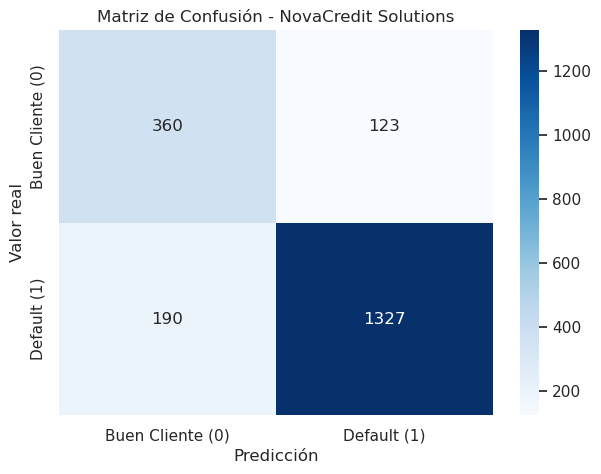

In [92]:
# ------------------------------------------------------------------------------
# matriz de confusion visual
# ------------------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Buen Cliente (0)', 'Default (1)'], 
            yticklabels=['Buen Cliente (0)', 'Default (1)'])
plt.ylabel('Valor real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión - NovaCredit Solutions')
plt.savefig('figs/2-matriz-confusion.png')
plt.show()

### ⤴️ Curva ROC

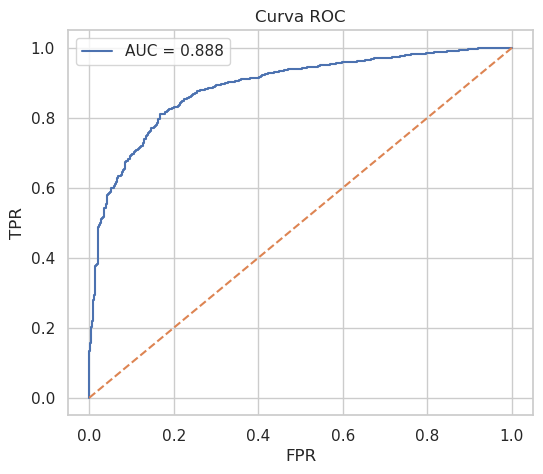

In [93]:
# ------------------------------------------------------------------------------
# curva roc
# ------------------------------------------------------------------------------
from sklearn.metrics import (roc_auc_score, roc_curve)

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_value = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.savefig('figs/3-curva-roc.png')
plt.show()

### ⤴️ Curva Precision-Recall

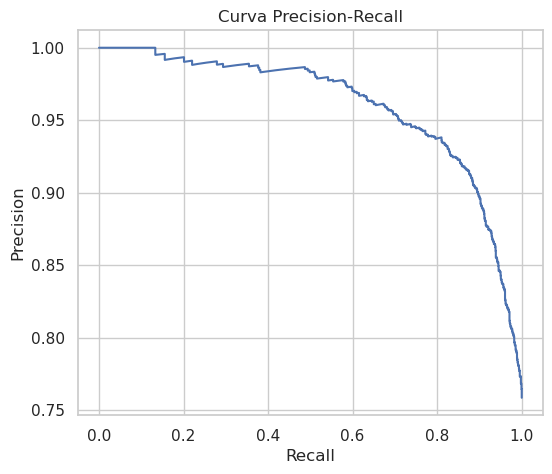

In [94]:
# ------------------------------------------------------------------------------
# curva precision recall
# ------------------------------------------------------------------------------
from sklearn.metrics import (precision_recall_curve)

prec, rec, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec)
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.savefig('figs/4-curva-p-recall.png')
plt.show()

## 🧑‍⚕️ Diagnóstico del modelo

Los resultados obtenidos en la prueba de simulación nos muestran la siguiente realidad estadística:

- **Accuracy** obtuvo un valor de 0.8435 (84.35%), lo que significa que de cada 100 decisiones que toma el modelo tiene una exactitud en 84 de ellas. Sin embargo, debido a que nuestra cartera de clientes tiene un 75% de defaults cargados en default_1 esta métrica no es la más conveniente para evaluar el modelo.

- El **AUC-ROC** nos da un valor de 0.8884, lo que indica que el modelo es muy capaz de separar matemáticamente a un cliente sano de un cliente de alto riesgo.

- Por otro lado el **Recall** tiene un valor de 0.8748 (87.48%), lo que significa que de todos los clientes que realmente cayeron en default, el modelo logró detectar al 87.48% a tiempo.

- Finalmente, **Precision** tiene un valor de 0.9152 (91.52%), lo que significa que cuando el modelo detecta aun cliente en la alerta de default, tiene razón en el 91.52% de los casos.

## 🏪 Impacto en el negocio

Analizando los 4 cuadrantes de la Matriz de Confusión, donde se evaluó la capacidad del modelo con respecto a default tenemos que:

- El modelo logró identificar a 1,327 clientes morosos (verdaderos positivos) antes de que ocurriera el daño, esto permitirá a la dirección frenar nuevas líneas de crédito o bien iniciar con estrategias de cobranza efectivas.

- Por otro lado el modelo predijo 360 buenos clientes nuevos, y estos resultaron ser clientes que pagaron a tiempo (verdaderos negativos), y gracias esto, se permitió aprobar y mantener 360 créditos de clientes rentables nuevos.

- En el caso de los falsos negativos, se detectaron 190 casos de costos ocultos, pues NovaCredit aprobó líneas de crédito a 190 personas que terminaron sin pagar el crédito. Aunque no es un grupo mayoritario, este grupo requiere atención y el diseño de una estrategia para reducir la perdida y descubrir los detalles del por que dejaron de pagar.

- Finalmente, en el caso de los falsos positivos, el modelo pudo detectar que NovaCredit negó el crédito a 123 buenos clientes, lo que terminará en convertirse en una pérdida de ingresos y riesgo de fuga de clientes potenciales. Sin embargo, en este escenario donde el default del 75% representa a una inmensa mayoría de clientes morosos, y revisando que el modelo ha sido capaz de frenar a 1,327 posibles nuevos clientes morosos, el riesgo de perdida de los 123 buenos clientes podría ser justificable.

### 🪶 Conclusión

El modelo realmente no es perfecto, pero es una herramienta que nos ayuda en la reducción de riesgo y esta demostrando ser efectivo. Cabe recalcar que al haber optimizado el modelo con la etiqueta class_weight='balanced', se ha logrado que el algoritmo priorice la detección del default sin destruir por completo la experiencia de los clientes buenos.

# 📦 Modelado no supervisado mediante clustering

En las secciones previas se ha optimizado un modelo Random Forest para predecir el default, en esta sección se buscará entender la estructura la cartera de clientes. De esta manera podremos entender el tipo de clientes que maneja NovaCredit y cómo pueden ser tratados.

## 📄 Justificación sobre el uso de la técnica K-Means

Para esta tarea de entendimiento de los clientes he seleccionado **K-Means** ya que es bastante sensible a la escala de todas las variables, y, dado que nuestro dataset ya fue estandarizado en la Actividad 1, **K-Means** funcionará de manera óptima, dándole el mismo peso a los ingresos que a los atrasos. 

Una gran ventaja para negocio de **K-Means** es que los clusters generados podrán tener *centroides claros*, como el cliente promedio de los grupos por ejemplo, lo cual facilitará con la asignación de etiquetas de negocio, por ejemplo *"Segmento Conservador"* o *"Segmento Endeudado"*.

Durante la ejecución del algoritmo, se excluirán las variables codificadas con *One-Hot*, como *región* o *producto*, del dataset preparado, y, se agruparan todos los clientes solamente por su **comportamiento financiero**, en base a las variables tales como *saldo_promedio, porcentaje_utilizacion, pagos_atrasados, etc*. De esta manera se podrán descubrir verdaderos patrones de riesgo en base a las influencias financieras.

## 📀 Preparación de K-Means

In [ ]:
# ------------------------------------------------------------------------------
# Preparación de K-Means y Configuración Visual
# ------------------------------------------------------------------------------

# configuración visual limpia
sns.set_theme(style="whitegrid", palette="muted")

display_mensaje("Seleccionando solo las variables continuas y de comportamiento...")

'''
Seleccionando solo las variables continuas y de comportamiento.
Se excluyen las variables One-Hot porque no son ideales para K-Means
'''
cols_clustering = [
    'edad', 'ingreso_mensual', 'antiguedad_cliente_meses', 'limite_credito', 
    'saldo_promedio', 'porcentaje_utilizacion', 'num_transacciones_mes', 
    'pagos_atrasados_12m', 'reclamos_12m'
]
X_cluster = df_prep[cols_clustering]

# mostrando las primeras filas de los datos escalados listos para agrupar
display(pd.DataFrame(X_cluster, columns=cols_clustering).head())


 --- Seleccionando solo las variables continuas y de comportamiento... --- 


,edad,ingreso_mensual,antiguedad_cliente_meses,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m
0,0.460,-0.235,-0.961,-0.539,-0.213,0.464,0.466,1.626,-0.488
1,-0.142,-0.468,3.467,-0.315,-0.320,-0.169,-0.699,-1.099,-0.488
2,0.632,-0.640,0.661,-0.885,-0.848,-0.803,-0.466,-0.191,0.324
3,1.578,-0.163,1.100,-0.444,-0.938,-1.436,0.933,-1.099,0.324
4,-0.228,1.104,0.223,1.465,-0.274,-1.119,1.166,0.718,0.324


## 💿 Aplicando K-Means - Primera Prueba

In [60]:
# ------------------------------------------------------------------------------
# Aplicando K-Means - Primera Prueba
# ------------------------------------------------------------------------------
from sklearn.cluster import KMeans

# modelo preliminar con 4 clusters
kmeans_preliminar = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_preliminar.fit(X_cluster)

# asignando las etiquetas generadas al dataset original
df_prep["cluster_kmeans"] = kmeans_preliminar.labels_

display_mensaje("Etiquetas preliminares asignadas con éxito.")
display(df_prep[['cluster_kmeans'] + cols_clustering].head())


 --- Etiquetas preliminares asignadas con éxito. --- 


,cluster_kmeans,edad,ingreso_mensual,antiguedad_cliente_meses,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m
0,2,0.460,-0.235,-0.961,-0.539,-0.213,0.464,0.466,1.626,-0.488
1,0,-0.142,-0.468,3.467,-0.315,-0.320,-0.169,-0.699,-1.099,-0.488
2,1,0.632,-0.640,0.661,-0.885,-0.848,-0.803,-0.466,-0.191,0.324
3,1,1.578,-0.163,1.100,-0.444,-0.938,-1.436,0.933,-1.099,0.324
4,1,-0.228,1.104,0.223,1.465,-0.274,-1.119,1.166,0.718,0.324


## 📊 Visualización inicial con PCA (solo 2 componentes)

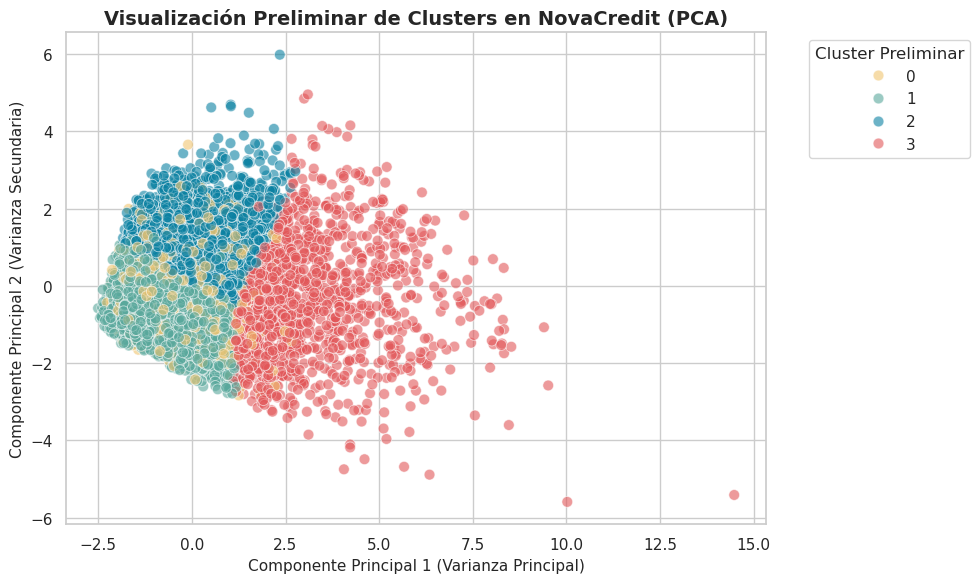

In [95]:
# ------------------------------------------------------------------------------
# Visualización inicial con PCA (Reducción a 2 componentes)
# ------------------------------------------------------------------------------
from sklearn.decomposition import PCA

# reduciendo a 2 componentes para poder graficar en un plano 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 6))
# scatterplot
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=df_prep["cluster_kmeans"], 
    palette=_paleta_muted_, s=60, alpha=0.6
)

# titulos
plt.title("Visualización Preliminar de Clusters en NovaCredit (PCA)", fontsize=14, fontweight='bold')
plt.xlabel("Componente Principal 1 (Varianza Principal)", fontsize=11)
plt.ylabel("Componente Principal 2 (Varianza Secundaria)", fontsize=11)
plt.legend(title="Cluster Preliminar", bbox_to_anchor=(1.05, 1), loc='upper left')
# show
plt.tight_layout()
plt.savefig('figs/5-k-means-test.png')
plt.show()


### 🔢 Determinar el número óptimo de clusters

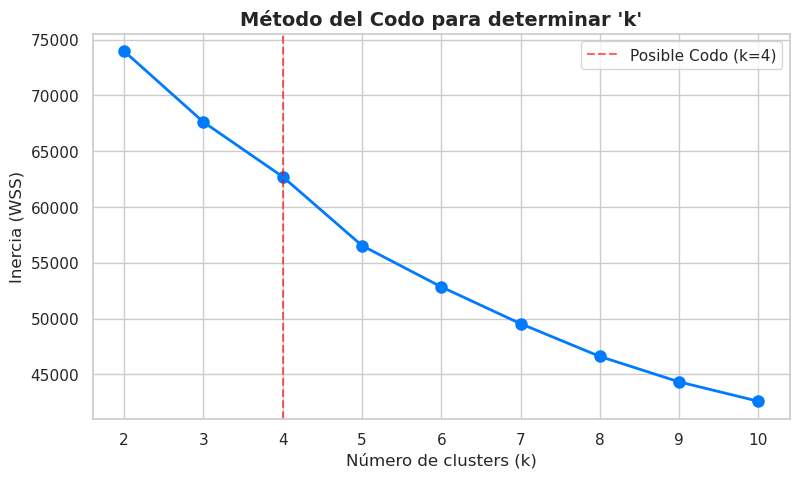

In [ ]:
# ------------------------------------------------------------------------------
# Determinando el número óptimo de clusters con el método del codo
# ------------------------------------------------------------------------------
wss = []  # Inercia

# probar valores de k de 2 a 10
K = range(2, 11)
for k in K:
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_eval.fit(X_cluster)
    wss.append(kmeans_eval.inertia_)

# grafica del método del codo
plt.figure(figsize=(9, 5))
plt.plot(K, wss, marker='o', color=_color_primary, linewidth=2, markersize=8)
plt.title("Método del Codo para determinar 'k'", fontsize=14, fontweight='bold')
plt.xlabel("Número de clusters (k)", fontsize=12)
plt.ylabel("Inercia (WSS)", fontsize=12)

# resaltando la mejor zona
plt.axvline(x=4, color=_color_danger, linestyle='--', alpha=0.6, label='Posible Codo (k=4)')
plt.legend()
plt.savefig('figs/6-metodo-codo.png')
plt.show()

### 🌂 Evaluación con el método Silhouette

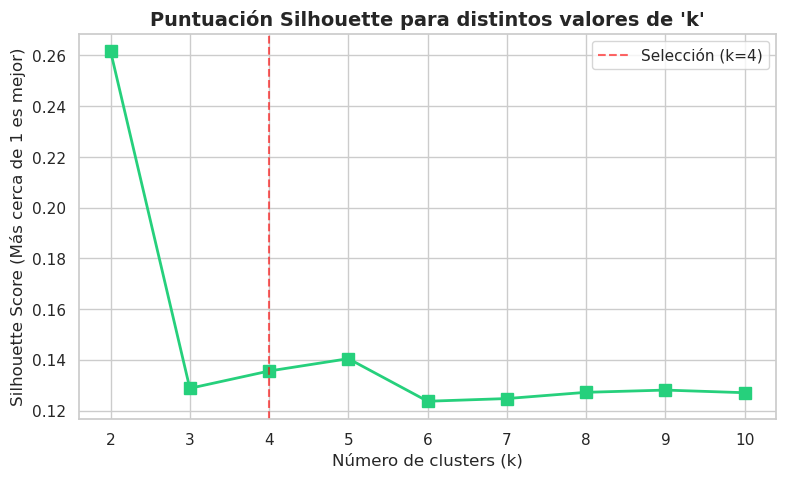

In [ ]:
# ------------------------------------------------------------------------------
# Evaluación con el metodo Silhouette
# ------------------------------------------------------------------------------
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K:
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)
    score = silhouette_score(X_cluster, kmeans_eval.labels_)
    silhouette_scores.append(score)

# grafica de silhouette
plt.figure(figsize=(9, 5))
plt.plot(K, silhouette_scores, marker='s', color=_color_tecmi_light, linewidth=2, markersize=8)
# titulos
plt.title("Puntuación Silhouette para distintos valores de 'k'", fontsize=14, fontweight='bold')
plt.xlabel("Número de clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score (Más cerca de 1 es mejor)", fontsize=12)
# resaltando la mejor zona
plt.axvline(x=4, color=_color_danger, linestyle='--', alpha=0.6, label='Selección (k=4)')
plt.legend()
plt.savefig('figs/7-silhouette.png')
plt.show()

## 🤖 Aplicación de K-Means final con k = 4

In [104]:
# ------------------------------------------------------------------------------
# Aplicando K-Means (Modelo Final)
# ------------------------------------------------------------------------------

k_optimo = 4
display_mensaje("Entrenando modelo final de K-Means con k=4")

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans_final.fit(X_cluster)

# etiquetas finales al DataFrame
df_prep["cluster_final"] = kmeans_final.labels_

'''
Nota sobre Centroides:
-> los datos de entrada ya están estandarizados desde la actividad 1
'''
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
print("✔️ Modelo entrenado y etiquetas guardadas.")


 --- Entrenando modelo final de K-Means con k=4 --- 
✔️ Modelo entrenado y etiquetas guardadas.


## 🏛️ Perfil de clusters

In [124]:
# ------------------------------------------------------------------------------
# Perfil de clusters
# ------------------------------------------------------------------------------
import matplotlib.ticker as mtick

display_mensaje("Perfil de los Clusters")
print("Valores > 0 indican que el cluster está por ENCIMA del promedio de la cartera.")
print("Valores < 0 indican que el cluster está por DEBAJO del promedio de la cartera.\n")

# asginación de nombres a cada cluster
#  sea mapean los numeros a nombres descriptivos para facilitar la lectura
nombres_estrategicos = {
    0: 'Leales Estabilizados',
    1: 'Inactivos Bajo Límite',
    2: 'Apalancados Crónicos',
    3: 'VIP Volátiles'
}

# nueva columna temporal para el reporte
df_prep['Perfil_Estrategico'] = df_prep['Cluster_Conductual'].map(nombres_estrategicos)

# Tabla de perfiles
cluster_profile = df_prep.groupby('Perfil_Estrategico')[cols_clustering].mean()

# métricas clave de negocio
cluster_profile['Tasa_Default_Real (%)'] = df_prep.groupby('Perfil_Estrategico')['default_12m'].mean() * 100
cluster_profile['Total_Clientes'] = df_prep.groupby('Perfil_Estrategico').size()

# orden de columnas
cols_ordenadas = ['Total_Clientes', 'Tasa_Default_Real (%)'] + cols_clustering
cluster_profile = cluster_profile[cols_ordenadas]

# mostrando el resumen
'''
# se emplea el estilo background_gradient para crear un mapa de calor en la tabla
# rojo = alto, azul = bajo, blanco = cero
'''
print("Leyenda \n -------------")
print(" 🔴 = Alto \n 🔵 = Bajo \n ⚪ = Cero")
display(cluster_profile.round(2).style.background_gradient(cmap='coolwarm', axis=0))


 --- Perfil de los Clusters --- 
Valores > 0 indican que el cluster está por ENCIMA del promedio de la cartera.
Valores < 0 indican que el cluster está por DEBAJO del promedio de la cartera.

Leyenda 
 -------------
 🔴 = Alto 
 🔵 = Bajo 
 ⚪ = Cero


,Total_Clientes,Tasa_Default_Real (%),edad,ingreso_mensual,antiguedad_cliente_meses,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m
Perfil_Estrategico,,,,,,,,,,,
Apalancados Crónicos,2691,78.930000,0.030000,-0.280000,-0.300000,-0.290000,0.310000,1.080000,-0.020000,-0.060000,0.070000
Inactivos Bajo Límite,4589,79.780000,0.000000,-0.310000,-0.360000,-0.330000,-0.580000,-0.660000,-0.010000,0.010000,-0.050000
Leales Estabilizados,1362,53.890000,-0.050000,-0.220000,1.890000,-0.220000,-0.260000,-0.130000,0.040000,0.060000,-0.060000
VIP Volátiles,1358,78.420000,-0.030000,1.810000,-0.080000,1.910000,1.610000,0.220000,0.040000,0.020000,0.110000


## 📊 Gráfica de riesgo por cluster

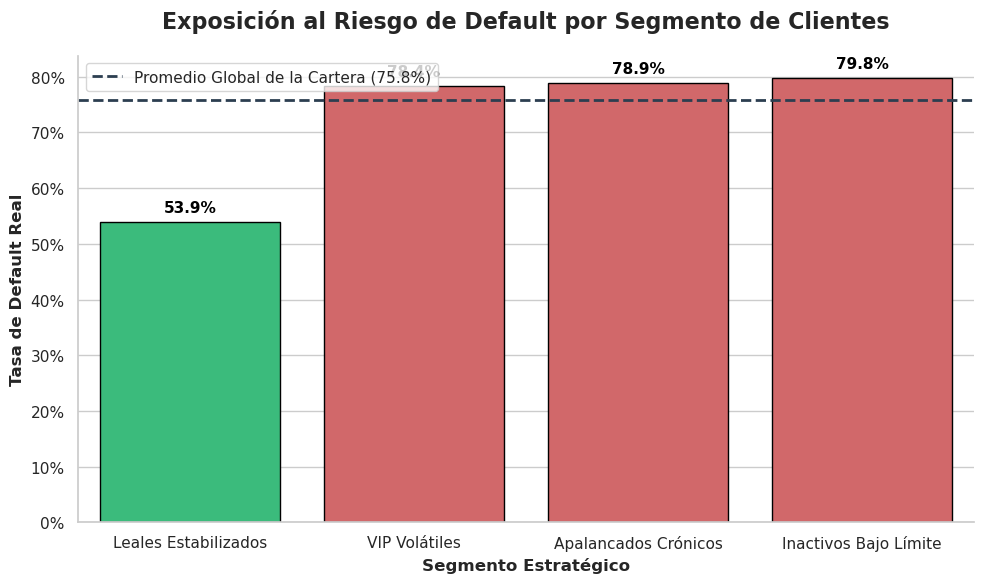

In [ ]:
# ------------------------------------------------------------------------------
# Grafica de riesgo de cada cluster
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# promedio global para la línea de referencia
promedio_global = df_prep['default_12m'].mean() * 100

# ordenando los clusters por tasa de default
profile_ordenado = cluster_profile.sort_values('Tasa_Default_Real (%)')

# gráfico de barras y asignacion de colores en base al %
colores = [_color_tecmi_light if tasa < promedio_global else _Red_ for tasa in profile_ordenado['Tasa_Default_Real (%)']]

# barplot
ax = sns.barplot(
    x=profile_ordenado.index, 
    y=profile_ordenado['Tasa_Default_Real (%)'], 
    palette=colores,
    edgecolor='black'
)

# títulos y etiquetas
plt.title('Exposición al Riesgo de Default por Segmento de Clientes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Segmento Estratégico', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Default Real', fontsize=12, fontweight='bold')

# formato del eje Y
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# línea de promedio global
plt.axhline(y=promedio_global, color='#2c3e50', linestyle='--', linewidth=2, 
            label=f'Promedio Global de la Cartera ({promedio_global:.1f}%)')

# etiquetas de datos sobre cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

# Limpiar los bordes de la gráfica para un look más moderno (opcional pero recomendado)
sns.despine()

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# limpiando la columna temporal
df_prep.drop(columns=['Perfil_Estrategico'], inplace=True)

## 📊 Visualización final de clusters con PCA (K-Means final)

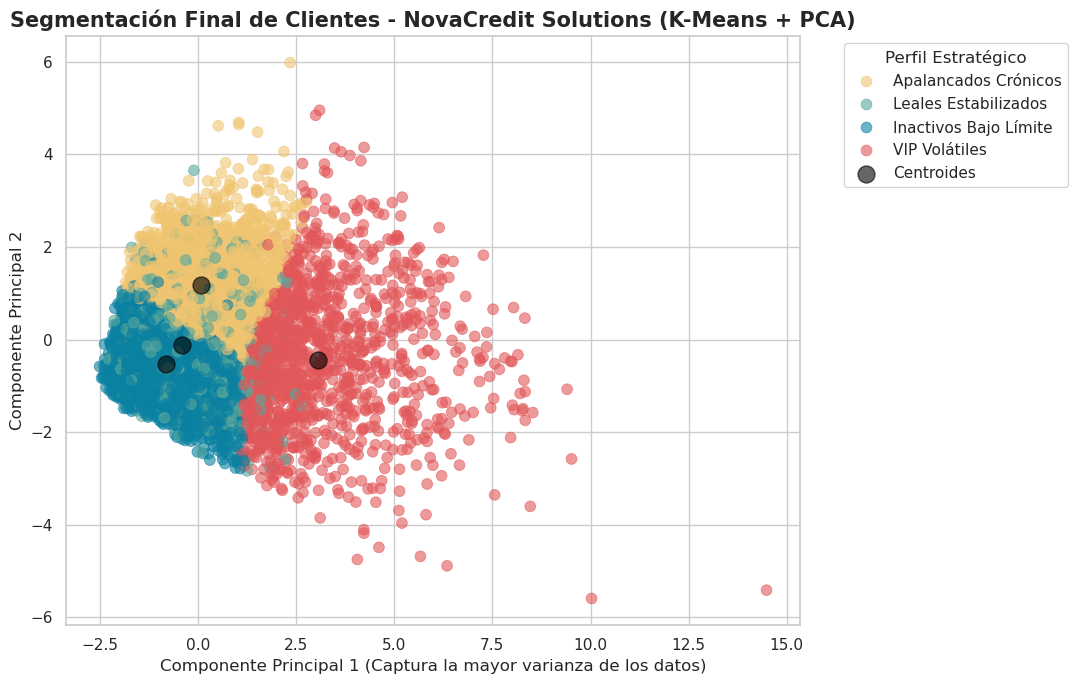

In [127]:
# ------------------------------------------------------------------------------
# Visualización final de clusters con pca + centroides
# ------------------------------------------------------------------------------
plt.figure(figsize=(11, 7))

# scatterplot de los clientes
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df_prep["cluster_final"].map(nombres_estrategicos), 
    palette=_paleta_muted_, s=60, alpha=0.6, edgecolor=None
)

# marca de centroides
plt.scatter(
    centroides_pca[:, 0], centroides_pca[:, 1],
    marker='o', s=150, c='black', alpha=0.6, label='Centroides'
)

# titulos
plt.title("Segmentación Final de Clientes - NovaCredit Solutions (K-Means + PCA)", fontsize=15, fontweight='bold')
plt.xlabel("Componente Principal 1 (Captura la mayor varianza de los datos)", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)

# leyenda
plt.legend(title="Perfil Estratégico", bbox_to_anchor=(1.05, 1), loc='upper left')

# show
plt.tight_layout()
plt.savefig("figs/8-k-means-final.png")
plt.show()

## ♟️ Clustering jerárquico aglomerativo y dendrograma



 --- Generando muestra y calculando enlaces jerárquicos... --- 


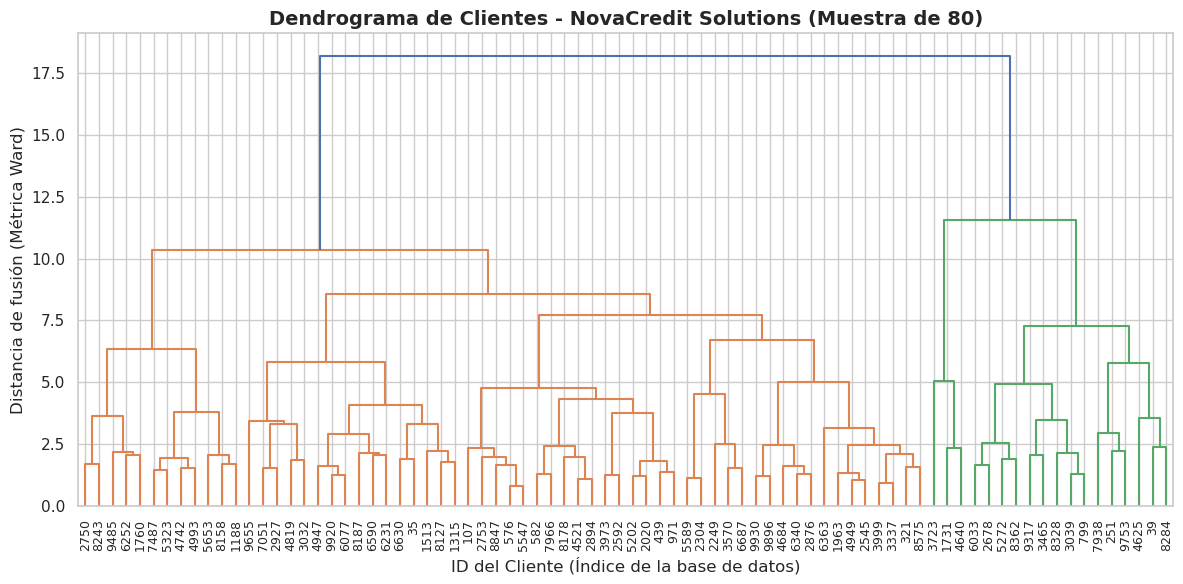

In [106]:
# ------------------------------------------------------------------------------
# Clustering jerárquico aglomerativo y dendrograma
# ------------------------------------------------------------------------------
from scipy.cluster.hierarchy import linkage, dendrogram

# graficas limpias
sns.set_theme(style="whitegrid")

display_mensaje("Generando muestra y calculando enlaces jerárquicos...")

'''
# en base a las pruebas realizadas, para el dendrograma es imposible visualizar 10,000 clientes de forma clara.
# se toma una muestra representativa de 80 clientes para entender la estructura.
'''
muestra = df_prep.sample(80, random_state=42)
X_muestra = muestra[cols_clustering]

# calculando el enlace jerárquico
'''
# el metodo 'ward' busca minimizar la varianza dentro de cada cluster al fusionarlos
'''
Z = linkage(X_muestra, method="ward")
# fig
plt.figure(figsize=(12, 6))

# aplicando un label identificativo a cada cliente de la muestra
dendrogram(
    Z, 
    labels=muestra.index.astype(str).tolist(), 
    leaf_rotation=90, 
    leaf_font_size=9,
    color_threshold=None
)

# titulos
plt.title("Dendrograma de Clientes - NovaCredit Solutions (Muestra de 80)", fontsize=14, fontweight='bold')
plt.xlabel("ID del Cliente (Índice de la base de datos)", fontsize=12)
plt.ylabel("Distancia de fusión (Métrica Ward)", fontsize=12)
# show
plt.tight_layout()
plt.savefig("figs/9-cluster-jerarquico.png")
plt.show()

## 👾 Asignando clusters jerárquicos

In [110]:
# ------------------------------------------------------------------------------
# Asignacion de clusters jerárquicos para compararlos
# ------------------------------------------------------------------------------
from sklearn.cluster import AgglomerativeClustering

display_mensaje("Entrenando modelo Jerárquico Aglomerativo en los 10,000 registros...")
print("(🗒️: Este algoritmo puede tomar unos segundos en calcular la matriz de distancias)")

# mModelo jerárquico aglomerativo con 4 clusters
agg = AgglomerativeClustering(
    n_clusters=4,
    metric="euclidean",   # metrica de distancia estándar para datos escalados
    linkage="ward"        # criterio de enlace compatible con distancia euclidiana
)

# ajuste del modelo y asignacion de clusters al dataset principal
df_prep["cluster_jerarquico"] = agg.fit_predict(X_cluster)

# resumen comparativo de clusters jerarquicos
resumen_jerarquico = (
    df_prep
    .groupby("cluster_jerarquico")[cols_clustering]
    .mean()
    .round(3)
)

# conteo de clientes por cluster
resumen_jerarquico["n_clientes"] = df_prep["cluster_jerarquico"].value_counts()

# reordenando las columnas
columnas_ordenadas = ["n_clientes"] + cols_clustering
resumen_jerarquico = resumen_jerarquico[columnas_ordenadas]

display_mensaje("Perfil de los Clusters Jerárquicos (Valores Estandarizados Z-Score) ===")

# mostrando el resumen
'''
# se emplea el estilo background_gradient para crear un mapa de calor en la tabla
# rojo = alto, azul = bajo, blanco = cero
'''
print("Leyenda \n -------------")
print(" 🔴 = Alto \n 🔵 = Bajo \n ⚪ = Cero")
display(resumen_jerarquico.style.background_gradient(cmap='coolwarm', axis=0))


 --- Entrenando modelo Jerárquico Aglomerativo en los 10,000 registros... --- 
(🗒️: Este algoritmo puede tomar unos segundos en calcular la matriz de distancias)

 --- Perfil de los Clusters Jerárquicos (Valores Estandarizados Z-Score) === --- 
Leyenda 
 -------------
 🔴 = Alto 
 🔵 = Bajo 
 ⚪ = Cero


,n_clientes,edad,ingreso_mensual,antiguedad_cliente_meses,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m
cluster_jerarquico,,,,,,,,,,
0,4096,-0.131000,0.185000,0.269000,0.227000,0.305000,0.452000,-0.195000,-0.009000,-0.057000
1,5339,0.089000,-0.379000,-0.205000,-0.408000,-0.495000,-0.391000,0.157000,0.020000,-0.095000
2,101,0.031000,-0.170000,-0.074000,-0.203000,2.002000,-0.080000,-0.051000,0.142000,7.743000
3,464,0.123000,2.765000,-0.005000,2.743000,2.572000,0.523000,-0.072000,-0.177000,-0.094000


## 🔢 Análisis del Número de Clusters (Elbow y Silhouette)

Para evitar segmentar al azar, he ejecutado un análisis sistemático probando diferentes valores de k (de 2 a 7).Método del Codo (Elbow / Inercia): La inercia representa qué tan "compactos" son los clusters. En nuestro dataset, la caída más pronunciada se detiene alrededor de $k=3$ o $k=4$, sugiriendo que añadir más segmentos no aporta una diferenciación estadísticamente útil.Puntuación Silhouette: Mide qué tan bien separado está un cluster de los demás. Aunque $k=2$ tiene el mayor score, dividir una cartera de 10,000 clientes en solo dos bloques (ej. ricos vs. pobres) es inútil para el negocio. El siguiente pico lógico, que equilibra granularidad comercial con separación matemática, es $k=4$.Por lo tanto, se seleccionó $k=4$ clusters para el desarrollo de estrategias comerciales diferenciadas.

## Interpretación de los Resultados y Estrategia de Negocio

He ejecutado el algoritmo KMeans(n_clusters=4) sobre nuestro dataset y analizado la media estandarizada de cada variable por cluster. Recuerda que, al estar escalado con Z-Score, un valor de $0$ es la media de la cartera, valores positivos $(>0)$ indican que el segmento está por encima del promedio general, y negativos $(<0)$ por debajo.He cruzado estos clusters con la variable objetivo real (Tasa_Default) para revelar el verdadero impacto de cada segmento:

🟢 Cluster 0: "Los Leales Estabilizados" (1,362 clientes)Perfil de Datos: Tienen una Antigüedad altísima ($Z=1.88$), saldos moderados y utilización por debajo de la media.Riesgo (Tasa de Default: 53.9%): Este es el mejor segmento de NovaCredit. Aunque el default general de la empresa es del 75%, este grupo tiene el riesgo más bajo (casi 22 puntos menos).Estrategia de Negocio: Retención Pura. Son clientes probados por el tiempo. No debemos molestarlos con cobranzas agresivas ante un primer atraso. Son los candidatos ideales para ofrecerles mejoras en la tasa de interés (cross-selling de seguros o créditos automotrices) para afianzar su lealtad.

🟡 Cluster 1: "Los Inactivos de Bajo Límite" (4,589 clientes - El segmento mayoritario)Perfil de Datos: Tienen los límites más bajos ($Z=-0.33$), saldos promedio muy bajos ($Z=-0.58$) y la utilización más baja ($Z=-0.66$). Son clientes de reciente adquisición (antigüedad negativa en Z).Riesgo (Tasa de Default: 79.8%): Riesgo alto.Estrategia de Negocio: Desarrollo Cuidadoso. Representan casi la mitad de la cartera. Tienen la tarjeta o línea de crédito pero apenas la usan, y cuando la usan, tienden a caer en default. NovaCredit debe implementar programas de educación financiera y no aumentar sus límites hasta que demuestren capacidad de pago constante a través de montos pequeños.

🟠 Cluster 2: "Los Apalancados Crónicos" (2,691 clientes)Perfil de Datos: Sus ingresos y límites están por debajo del promedio, pero tienen un porcentaje de utilización altísimo ($Z=1.07$) y saldos promedio altos ($Z=0.31$).Riesgo (Tasa de Default: 78.9%): Riesgo alto.Estrategia de Negocio: Contención de Riesgo. Estos clientes están "maximizando" sus tarjetas. Están viviendo del crédito sin la capacidad de ingresos para respaldarlo. NovaCredit debe frenar los incrementos de línea de crédito inmediatamente para este segmento y ofrecer planes de consolidación de deuda a tasa fija para ayudarles a desapalancarse antes de que se vuelvan incobrables.

🔴 Cluster 3: "Los VIP Volátiles" (1,358 clientes)Perfil de Datos: Tienen Ingresos masivos ($Z=1.80$), Límites de crédito altísimos ($Z=1.91$) y manejan Saldos muy elevados ($Z=1.60$).Riesgo (Tasa de Default: 78.4%): Riesgo inesperadamente alto.Estrategia de Negocio: Auditoría de Alta Prioridad. Este es el hallazgo más contraintuitivo y peligroso. Son clientes de alto poder adquisitivo, pero fallan en casi la misma proporción que los segmentos de bajos ingresos (78%). Dado el volumen de dinero que manejan, un default aquí genera pérdidas millonarias (pueden ser los responsables del desangre de la empresa). La estrategia debe ser la creación de una unidad de Gestión de Cuentas Premium que supervise estos saldos de cerca y verifique que no sean fraudes corporativos o de suplantación de identidad de alto nivel.

nombres_estrategicos = {
    0: 'Leales Estabilizados',
    1: 'Inactivos Bajo Límite',
    2: 'Apalancados Crónicos',
    3: 'VIP Volátiles'
}